In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

PROJECT_ROOT: /Users/amirhosseinlatifinavid/Desktop/Programming/Python /quant-ml-backtester
ARTIFACTS_DIR: /Users/amirhosseinlatifinavid/Desktop/Programming/Python /quant-ml-backtester/artifacts


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from quant_ml.models import time_split, fit_predict_logistic, fit_predict_rf
from quant_ml.signals import make_weekly_top_n_signals, equal_weight_from_signal
from quant_ml.baseline import (
    compute_momentum_signal,
    equal_weight_portfolio,
    compute_strategy_returns,
)
from quant_ml.analytics import (
    compute_metrics,
    build_drawdown_series,
    portfolio_to_dashboard_frame,
    metrics_dict_to_frame,
    extract_logistic_feature_importance,
    extract_rf_feature_importance,
)
from quant_ml.config import INTERIM_DATA_DIR

In [3]:
df = pd.read_parquet(INTERIM_DATA_DIR / "model_dataset_v1.parquet")
df["date"] = pd.to_datetime(df["date"])
df.shape

(20490, 27)

In [4]:
TRAIN_END_DATE = "2020-12-31"

feature_cols = [
    "ret_1d", "ret_5d", "ret_20d", "ret_60d",
    "ma_ratio_20", "ma_ratio_50", "ma_ratio_100", "ma_cross_20_50",
    "vol_20d", "vol_60d",
    "volume_z_20", "volume_ratio_20",
    "fed_funds", "cpi", "unemployment", "10y_treasury", "2y_treasury", "term_spread",
]

target_col = "target_up_5d"

split = time_split(df, train_end_date=TRAIN_END_DATE)
train_df = split.train
test_df = split.test

print(train_df.shape, test_df.shape)

(12996, 27) (7494, 27)


In [5]:
baseline_df = test_df.copy()
baseline_df = compute_momentum_signal(baseline_df)
baseline_df = equal_weight_portfolio(baseline_df)
baseline_portfolio = compute_strategy_returns(baseline_df)
baseline_metrics = compute_metrics(baseline_portfolio)

baseline_metrics

{'annual_return': 0.0018727949059371696,
 'annual_volatility': 0.15260762027761265,
 'sharpe': 0.012260530337100105,
 'max_drawdown': -0.39515909104736646}

In [6]:
log_model, log_preds = fit_predict_logistic(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
)

log_df = make_weekly_top_n_signals(
    log_preds,
    score_col="proba_up",
    top_n=2,
)
log_df = equal_weight_from_signal(log_df)
log_portfolio = compute_strategy_returns(log_df)
log_metrics = compute_metrics(log_portfolio)

log_metrics

{'annual_return': 0.09289594599747075,
 'annual_volatility': 0.16192683950126283,
 'sharpe': 0.5486839800570537,
 'max_drawdown': -0.20351268568888947}

In [7]:
rf_model, rf_preds = fit_predict_rf(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
)

rf_df = make_weekly_top_n_signals(
    rf_preds,
    score_col="proba_up",
    top_n=3,
)
rf_df = equal_weight_from_signal(rf_df)
rf_portfolio = compute_strategy_returns(rf_df)
rf_metrics = compute_metrics(rf_portfolio)

rf_metrics

{'annual_return': 0.10448523400546428,
 'annual_volatility': 0.16290281661201186,
 'sharpe': 0.6101734472497135,
 'max_drawdown': -0.2691122506367897}

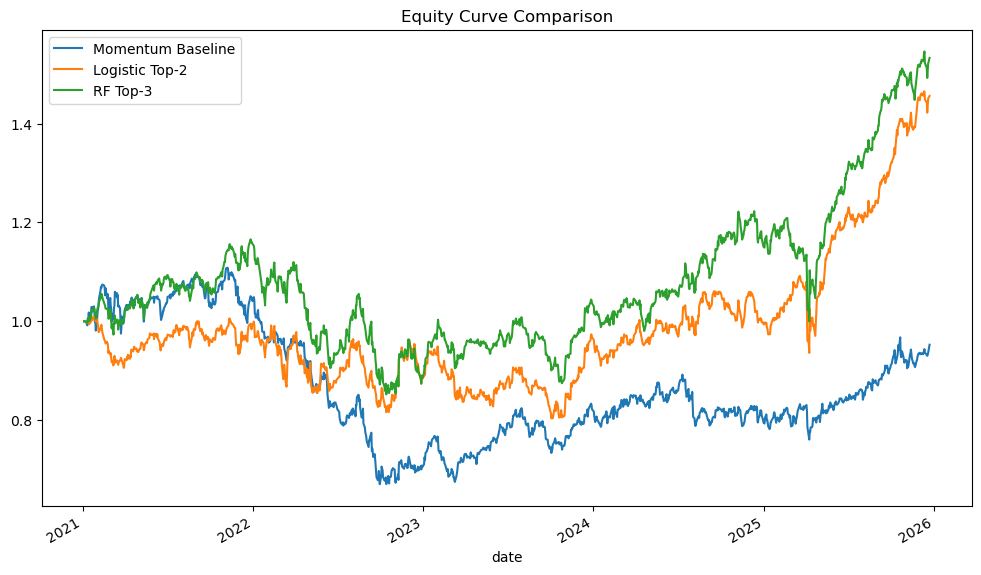

In [8]:
common_index = baseline_portfolio.index
common_index = common_index.intersection(log_portfolio.index)
common_index = common_index.intersection(rf_portfolio.index)

baseline_aligned = baseline_portfolio.loc[common_index].copy()
log_aligned = log_portfolio.loc[common_index].copy()
rf_aligned = rf_portfolio.loc[common_index].copy()

plt.figure(figsize=(12, 7))
baseline_aligned["cum_return"].plot(label="Momentum Baseline")
log_aligned["cum_return"].plot(label="Logistic Top-2")
rf_aligned["cum_return"].plot(label="RF Top-3")
plt.legend()
plt.title("Equity Curve Comparison")
plt.show()

In [9]:
log_importance = extract_logistic_feature_importance(log_model, feature_cols)
rf_importance = extract_rf_feature_importance(rf_model, feature_cols)

log_importance.head(10), rf_importance.head(10)

(          feature  importance  abs_importance
 0    ma_ratio_100   -0.278668        0.278668
 1         vol_20d    0.166181        0.166181
 2         vol_60d   -0.162246        0.162246
 3  ma_cross_20_50    0.122177        0.122177
 4             cpi    0.106855        0.106855
 5       fed_funds    0.090277        0.090277
 6     ma_ratio_50    0.088534        0.088534
 7     volume_z_20   -0.084270        0.084270
 8     2y_treasury   -0.073939        0.073939
 9    10y_treasury   -0.056292        0.056292,
           feature  importance  abs_importance
 0    ma_ratio_100    0.094893        0.094893
 1         vol_20d    0.094439        0.094439
 2             cpi    0.077830        0.077830
 3         vol_60d    0.069109        0.069109
 4  ma_cross_20_50    0.068510        0.068510
 5          ret_5d    0.058396        0.058396
 6     ma_ratio_20    0.058153        0.058153
 7         ret_60d    0.055108        0.055108
 8     term_spread    0.053690        0.053690
 9     2y_tr

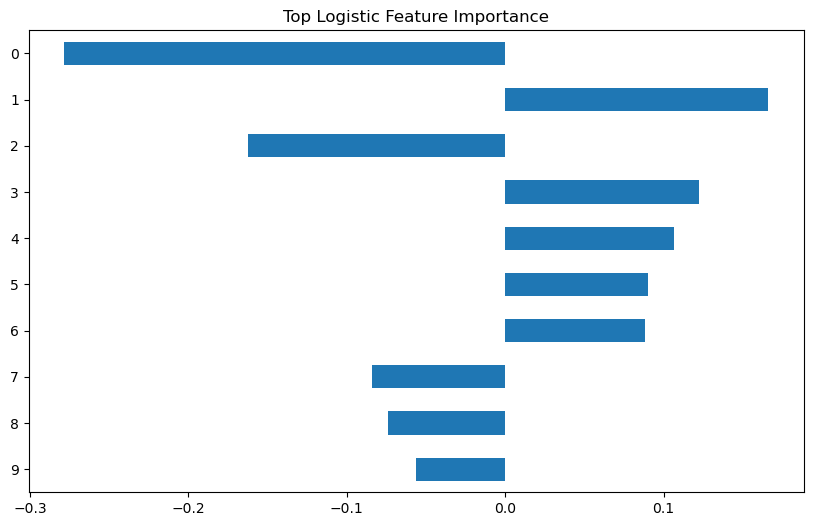

In [10]:
plt.figure(figsize=(10, 6))
log_importance.head(10).sort_values("abs_importance")["importance"].plot(kind="barh")
plt.title("Top Logistic Feature Importance")
plt.show()

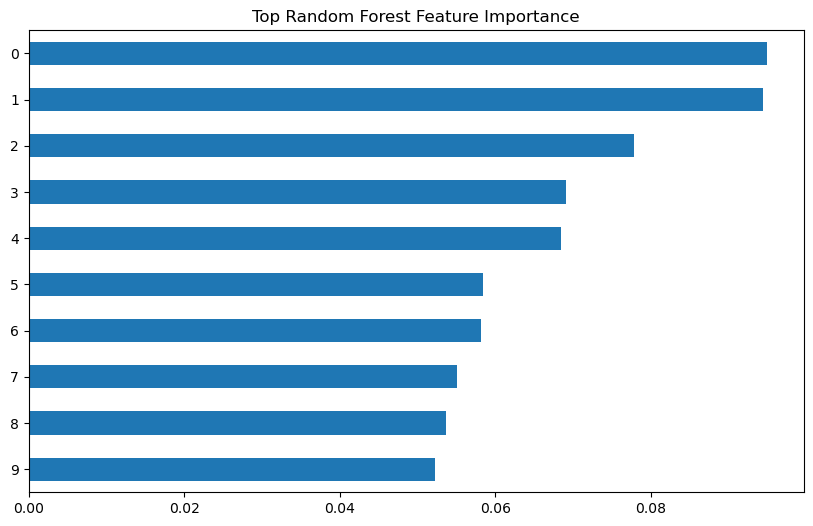

In [11]:
plt.figure(figsize=(10, 6))
rf_importance.head(10).sort_values("abs_importance")["importance"].plot(kind="barh")
plt.title("Top Random Forest Feature Importance")
plt.show()

In [12]:
metrics_table = pd.concat([
    metrics_dict_to_frame(compute_metrics(baseline_aligned), "momentum_baseline"),
    metrics_dict_to_frame(compute_metrics(log_aligned), "logistic_top2"),
    metrics_dict_to_frame(compute_metrics(rf_aligned), "rf_top3"),
], ignore_index=True)

metrics_table

,strategy_name,annual_return,annual_volatility,sharpe,max_drawdown
0,momentum_baseline,0.001873,0.152608,0.012261,-0.395159
1,logistic_top2,0.092896,0.161927,0.548684,-0.203513
2,rf_top3,0.104485,0.162903,0.610173,-0.269112


In [13]:
dashboard_curves = pd.concat([
    portfolio_to_dashboard_frame(baseline_aligned, "momentum_baseline"),
    portfolio_to_dashboard_frame(log_aligned, "logistic_top2"),
    portfolio_to_dashboard_frame(rf_aligned, "rf_top3"),
], ignore_index=True)

dashboard_curves.head()

,date,gross_return,cost,net_return,cum_return,strategy_name
0,2021-01-04,0.0,0.000,0.000,1.000,momentum_baseline
1,2021-01-05,0.0,0.000,0.000,1.000,momentum_baseline
2,2021-01-06,0.0,0.000,0.000,1.000,momentum_baseline
3,2021-01-07,0.0,0.000,0.000,1.000,momentum_baseline
4,2021-01-08,0.0,0.001,-0.001,0.999,momentum_baseline


In [14]:
baseline_dd = portfolio_to_dashboard_frame(
    build_drawdown_series(baseline_aligned),
    "momentum_baseline",
)
log_dd = portfolio_to_dashboard_frame(
    build_drawdown_series(log_aligned),
    "logistic_top2",
)
rf_dd = portfolio_to_dashboard_frame(
    build_drawdown_series(rf_aligned),
    "rf_top3",
)

dashboard_drawdowns = pd.concat([baseline_dd, log_dd, rf_dd], ignore_index=True)
dashboard_drawdowns.head()

,date,gross_return,cost,net_return,cum_return,rolling_peak,drawdown,strategy_name
0,2021-01-04,0.0,0.000,0.000,1.000,1.0,0.000,momentum_baseline
1,2021-01-05,0.0,0.000,0.000,1.000,1.0,0.000,momentum_baseline
2,2021-01-06,0.0,0.000,0.000,1.000,1.0,0.000,momentum_baseline
3,2021-01-07,0.0,0.000,0.000,1.000,1.0,0.000,momentum_baseline
4,2021-01-08,0.0,0.001,-0.001,0.999,1.0,-0.001,momentum_baseline


In [15]:
metrics_table.to_csv(ARTIFACTS_DIR / "dashboard_metrics_table.csv", index=False)
metrics_table.to_parquet(ARTIFACTS_DIR / "dashboard_metrics_table.parquet", index=False)

dashboard_curves.to_csv(ARTIFACTS_DIR / "dashboard_curves.csv", index=False)
dashboard_curves.to_parquet(ARTIFACTS_DIR / "dashboard_curves.parquet", index=False)

dashboard_drawdowns.to_csv(ARTIFACTS_DIR / "dashboard_drawdowns.csv", index=False)
dashboard_drawdowns.to_parquet(ARTIFACTS_DIR / "dashboard_drawdowns.parquet", index=False)

log_importance.to_csv(ARTIFACTS_DIR / "logistic_feature_importance.csv", index=False)
log_importance.to_parquet(ARTIFACTS_DIR / "logistic_feature_importance.parquet", index=False)

rf_importance.to_csv(ARTIFACTS_DIR / "rf_feature_importance.csv", index=False)
rf_importance.to_parquet(ARTIFACTS_DIR / "rf_feature_importance.parquet", index=False)

print("Saved dashboard-ready artifacts.")

Saved dashboard-ready artifacts.


In [16]:
sorted([p.name for p in ARTIFACTS_DIR.iterdir()])

['.DS_Store',
 'benchmark_portfolio_logistic_top2.parquet',
 'best_portfolio_rf_top3.parquet',
 'dashboard_curves.csv',
 'dashboard_curves.parquet',
 'dashboard_drawdowns.csv',
 'dashboard_drawdowns.parquet',
 'dashboard_metrics_table.csv',
 'dashboard_metrics_table.parquet',
 'experiment_results.csv',
 'experiment_results.parquet',
 'logistic_feature_importance.csv',
 'logistic_feature_importance.parquet',
 'rf_feature_importance.csv',
 'rf_feature_importance.parquet']